In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("../data/raw/mobile_game_inapp_purchases.csv")
df["HasPurchased"] = df["InAppPurchaseAmount"].notna().astype(int)
df.head()

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate,HasPurchased
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,2025-03-19,1
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,2025-06-08,1
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,2025-06-02,1
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,2025-04-01,1
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,2025-05-05,1


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   UserID                         3024 non-null   object 
 1   Age                            2964 non-null   float64
 2   Gender                         2964 non-null   object 
 3   Country                        2964 non-null   object 
 4   Device                         2964 non-null   object 
 5   GameGenre                      2964 non-null   object 
 6   SessionCount                   3024 non-null   int64  
 7   AverageSessionLength           3024 non-null   float64
 8   SpendingSegment                3024 non-null   object 
 9   InAppPurchaseAmount            2888 non-null   float64
 10  FirstPurchaseDaysAfterInstall  2888 non-null   float64
 11  PaymentMethod                  2888 non-null   object 
 12  LastPurchaseDate               2888 non-null   o

UserID                             0
Age                               60
Gender                            60
Country                           60
Device                            60
GameGenre                         60
SessionCount                       0
AverageSessionLength               0
SpendingSegment                    0
InAppPurchaseAmount              136
FirstPurchaseDaysAfterInstall    136
PaymentMethod                    136
LastPurchaseDate                 136
HasPurchased                       0
dtype: int64

In [3]:
total = len(df)
purchasers = df["HasPurchased"].sum()
print(f"전체 유저: {total}, 결제 유저: {purchasers}, 전환율: {purchasers/total*100:.1f}%")

seg = df.groupby("SpendingSegment").agg(
    user_count=("UserID", "count"),
    revenue=("InAppPurchaseAmount", "sum")
)
seg["rev_pct"] = seg["revenue"] / seg["revenue"].sum() * 100
seg

전체 유저: 3024, 결제 유저: 2888, 전환율: 95.5%


,user_count,revenue,rev_pct
SpendingSegment,,,
Dolphin,412,96288.80,32.501527
Minnow,2544,24387.37,8.231765
Whale,68,175583.14,59.266708


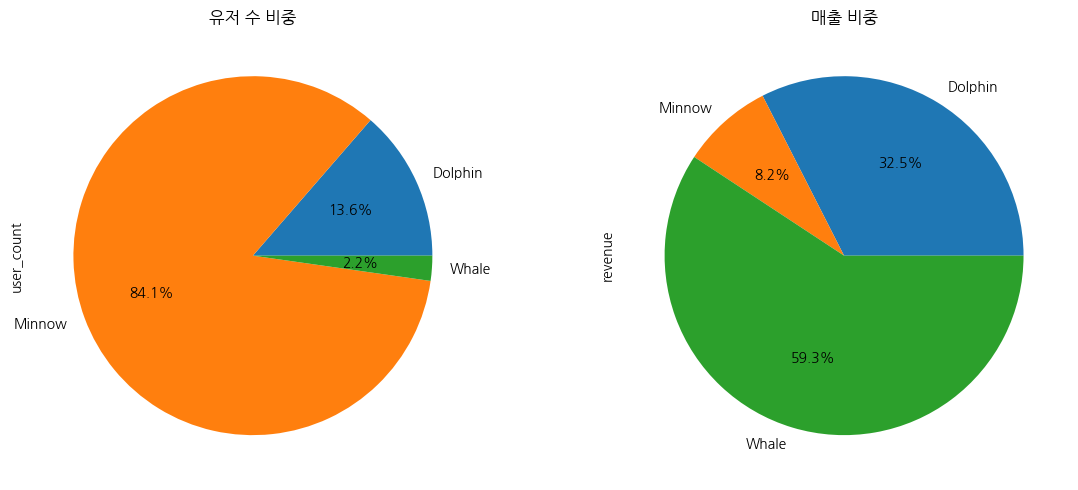

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
seg["user_count"].plot(kind="pie", autopct="%1.1f%%", ax=ax[0], title="유저 수 비중")
seg["revenue"].plot(kind="pie", autopct="%1.1f%%", ax=ax[1], title="매출 비중")
plt.tight_layout()
plt.show()

In [5]:
genre_summary = df.groupby("GameGenre").agg(
    total=("UserID", "count"),
    revenue=("InAppPurchaseAmount", "sum")
)
genre_summary["arpu"] = genre_summary["revenue"] / genre_summary["total"]
genre_summary.sort_values("arpu", ascending=False)


,total,revenue,arpu
GameGenre,,,
Racing,191,29163.56,152.688796
Battle Royale,189,28046.79,148.395714
Strategy,198,27066.62,136.700101
MOBA,181,24190.19,133.647459
Fighting,181,24177.92,133.579669
MMORPG,198,18444.36,93.153333
Adventure,170,15712.46,92.426235
Role Playing,193,17030.56,88.241244
Simulation,219,17804.21,81.297763
